Classes do Alvo encontradas (em MAIÚSCULAS): ['HIGH', 'LOW', 'MEDIUM', 'NONE', 'VERY_HIGH']
Shape final do Treino (X_train): (6812, 33)
Número de features: 33
A calcular o Cross-Validation do Stack Classifier v54...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   29.2s finished



Validação concluída em 0.49 minutos.
MELHOR ACCURACY (Stacking v54): 0.81547

--- [FIM DO PIPELINE] ---
Ficheiro 'submission_v54_CLASSIFIER_STACK.csv' criado com sucesso!
   RowId Speed_Diff
0      1       None
1      2     Medium
2      3       None
3      4     Medium
4      5        Low

   RELATÓRIO DETALHADO E VISUALIZAÇÃO (STACKING CLASSIFIER v54)
[SUCESSO] Imagem 'matriz_confusao_hetero_v54_laranja.png' guardada.


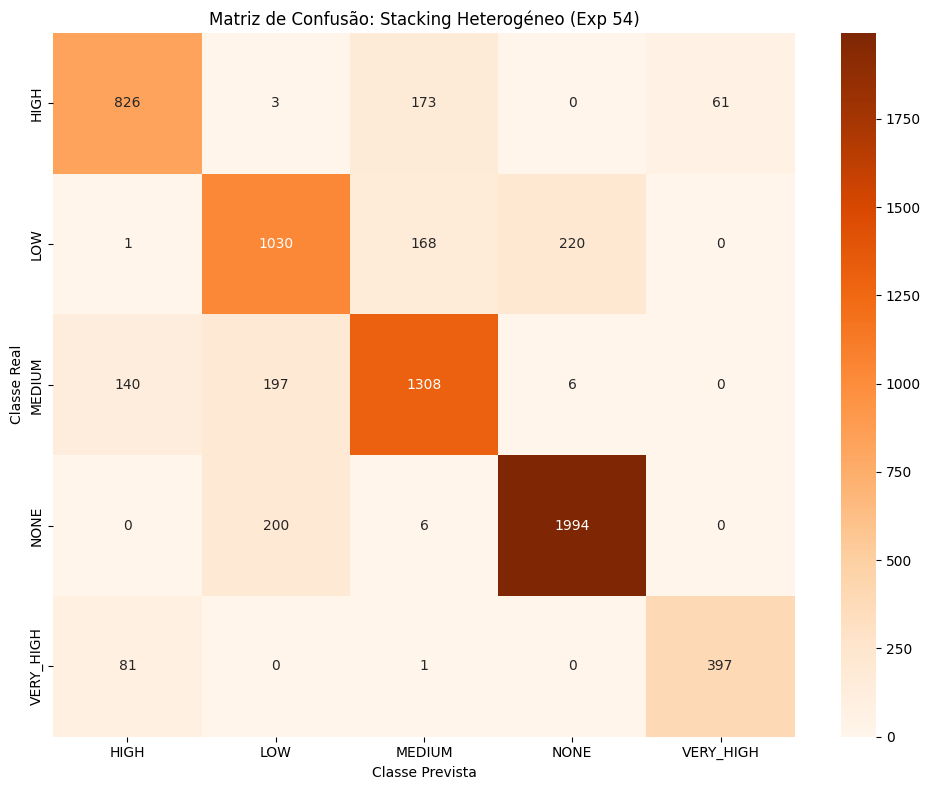


--- Métricas de Classificação (Validação Cruzada) ---
              precision  recall  f1-score  support
HIGH          0.788      0.777   0.783     1063   
LOW           0.720      0.726   0.723     1419   
MEDIUM        0.790      0.792   0.791     1651   
NONE          0.898      0.906   0.902     2200   
VERY_HIGH     0.867      0.829   0.847      479   
accuracy      0.815      0.815   0.815        0   
macro avg     0.813      0.806   0.809     6812   
weighted avg  0.816      0.815   0.815     6812   

[INFO] Tabela exportada para CSV.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import warnings
import time 

warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
warnings.filterwarnings('ignore', category=Warning) 


def formatar_celula(series_coluna):
    s = series_coluna.astype(str).replace('NULL', pd.NA)
    s = s.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
    s = s.str.upper()
    s = s.str.replace(r'[^A-Z0-9]+', '_', regex=True)
    s = s.str.strip('_')
    s = s.replace('', pd.NA)
    return s

def preprocessar_dados(df, colunas_scaler_treinadas=None, scaler=None):
    if 'RowId' not in df.columns and 'AVERAGE_SPEED_DIFF' not in df.columns:
        df_final_row_ids = np.arange(1, len(df) + 1)
    else:
        df_final_row_ids = None

    cols_to_transform = ['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN']
    for col in cols_to_transform:
        if col in df.columns:
            df[col] = formatar_celula(df[col])

    cols_to_drop_base = ['city_name', 'AVERAGE_RAIN', 'AVERAGE_PRECIPITATION', 'record_date']
    
    try:
        df['record_date_dt'] = pd.to_datetime(df['record_date'], format='mixed', dayfirst=True)
        df['Hora_sin'] = np.sin(2 * np.pi * df['record_date_dt'].dt.hour/24)
        df['Hora_cos'] = np.cos(2 * np.pi * df['record_date_dt'].dt.hour/24)
        df['Mes_sin'] = np.sin(2 * np.pi * df['record_date_dt'].dt.month/12)
        df['Mes_cos'] = np.cos(2 * np.pi * df['record_date_dt'].dt.month/12)
        df['DIA_SEMANA'] = df['record_date_dt'].dt.dayofweek
        df['IS_WEEKEND'] = df['DIA_SEMANA'].isin([5, 6]).astype(int)
        rush_hours = [7, 8, 9, 17, 18, 19]
        df['IS_RUSH_HOUR'] = df['record_date_dt'].dt.hour.isin(rush_hours).astype(int)
        df = df.drop(columns=['record_date_dt'])
    except KeyError:
        pass

    cols_existentes_drop = [col for col in cols_to_drop_base if col in df.columns]
    df = df.drop(columns=cols_existentes_drop)

    if 'AVERAGE_CLOUDINESS' in df.columns:
        df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].replace('NAN', np.nan)
        df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].fillna('NONE')

    cols_to_onehot = ['LUMINOSITY', 'AVERAGE_CLOUDINESS', 'DIA_SEMANA']
    for col in cols_to_onehot:
        if col in df.columns:
            prefix = col[:3].upper()
            if col == 'DIA_SEMANA': prefix = 'DAY'
            dummies = pd.get_dummies(df[col], prefix=prefix, dtype=int, sparse=False)
            df = pd.concat([df, dummies], axis=1)
            df = df.drop(col, axis=1)

    cols_to_normalize = [
        'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME',
        'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY',
        'AVERAGE_WIND_SPEED', 'IS_WEEKEND', 'IS_RUSH_HOUR',
        'Hora_sin', 'Hora_cos', 'Mes_sin', 'Mes_cos'
    ]
    cols_existentes_normalize = [col for col in cols_to_normalize if col in df.columns]
    
    if scaler is None:
        scaler = MinMaxScaler()
        if cols_existentes_normalize:
            df[cols_existentes_normalize] = scaler.fit_transform(df[cols_existentes_normalize])
        return df, scaler, cols_existentes_normalize, df_final_row_ids
    else:
        cols_para_scaler_teste = [col for col in colunas_scaler_treinadas if col in df.columns]
        if cols_para_scaler_teste:
            df[cols_para_scaler_teste] = scaler.transform(df[cols_para_scaler_teste])
        return df, None, None, df_final_row_ids


# --- CARREGAMENTO E PROCESSAMENTO ---
df_train = pd.read_csv("training_data.csv", delimiter=",", encoding="latin-1")
df_test = pd.read_csv("test_data.csv", delimiter=",", encoding="latin-1")
y_train_raw = df_train.pop('AVERAGE_SPEED_DIFF')
test_row_ids = np.arange(1, len(df_test) + 1)



X_train, scaler, colunas_scaler, _ = preprocessar_dados(df_train)
le = LabelEncoder()
y_train_formatado = formatar_celula(y_train_raw).replace('NAN', 'NONE').fillna('NONE')
y_train_encoded = le.fit_transform(y_train_formatado)
print(f"Classes do Alvo encontradas (em MAIÚSCULAS): {list(le.classes_)}")

X_test, _, _, _ = preprocessar_dados(df_test, colunas_scaler_treinadas=colunas_scaler, scaler=scaler)


# --- ALINHAMENTO DE COLUNAS ---
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train = X_train.reindex(columns=X_test.columns, fill_value=0)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
print(f"Shape final do Treino (X_train): {X_train.shape}")
print(f"Número de features: {X_train.shape[1]}") # 33


# --- VALIDAÇÃO DO ENSEMBLE ---
estimators = [
    ('xgb', XGBClassifier(
        learning_rate=0.08, max_depth=5, n_estimators=100,
        subsample=0.7, colsample_bytree=0.9,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=10, 
        n_jobs=-1
    )),
    ('gnb', GaussianNB())
]
meta_model = LogisticRegression(random_state=42, n_jobs=-1)

stack_clf_hetero = StackingClassifier(
    estimators=estimators, 
    final_estimator=meta_model, 
    cv=5,
    n_jobs=-1
)

print("A calcular o Cross-Validation do Stack Classifier v54...")
start_time = time.time()
scores = cross_val_score(stack_clf_hetero, X_train, y_train_encoded, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
end_time = time.time()

print(f"\nValidação concluída em {(end_time - start_time) / 60:.2f} minutos.")
print(f"MELHOR ACCURACY (Stacking v54): {np.mean(scores):.5f}")


# --- TREINO DO MODELO FINAL ---
stack_clf_hetero.fit(X_train, y_train_encoded)

y_pred_encoded = stack_clf_hetero.predict(X_test)
y_pred_labels_upper = le.inverse_transform(y_pred_encoded)
y_pred_labels_final = pd.Series(y_pred_labels_upper).str.title()

submission_df = pd.DataFrame({
    'RowId': test_row_ids,
    'Speed_Diff': y_pred_labels_final
})

submission_df.to_csv('submission_v54_CLASSIFIER_STACK.csv', index=False)

print("Ficheiro 'submission_v54_CLASSIFIER_STACK.csv' criado com sucesso!")
print(submission_df.head())


print("\n" + "="*80)
print("   RELATÓRIO DETALHADO E VISUALIZAÇÃO (STACKING CLASSIFIER v54)")
print("="*80)


y_pred_cv = cross_val_predict(stack_clf_hetero, X_train, y_train_encoded, cv=5, n_jobs=-1)
cm = confusion_matrix(y_train_encoded, y_pred_cv)
classes_nomes = list(le.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=classes_nomes, yticklabels=classes_nomes)
plt.title('Matriz de Confusão: Stacking Heterogéneo (Exp 54)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.savefig('matriz_confusao_hetero_v54_laranja.png', dpi=300)
print("[SUCESSO] Imagem 'matriz_confusao_hetero_v54_laranja.png' guardada.")
plt.show()


print("\n--- Métricas de Classificação (Validação Cruzada) ---")
report_dict = classification_report(y_train_encoded, y_pred_cv, target_names=classes_nomes, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

df_report = df_report.round(3)
df_report['support'] = df_report['support'].astype(int)
print(df_report.to_string(justify='left'))

df_report.to_csv('relatorio_metricas_hetero_v54.csv')
print("\n[INFO] Tabela metricas exportada para CSV.")